In [9]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Experiment 1:
### Input Neurons (SpikeGenerator):
Pattern A: N_0 fires at 10ms, N_1 fires at 20ms, N_3 fires at 30ms \
Pattern B: N_1 fires at 10ms, N_0 fires at 25ms, N_3 fires at 40ms

We build the input as 2 neurons in a spike generating group that mimics the following: \
Pattern A fires, 50ms gap, Pattern B fires ... 50 times

### Excitatory Neurons:
There are 10 total excitatory neurons modelled by the following simplest form of a current based LIF neuron equation: \
$\frac{dv}{dt} = -\frac{v}{tau}$ \
Using this simple equation means we can use the exact solution. 

### Synapses:
The synapses follow the standard STDP rules: 
* Define pre and post traces per synapse that decay after spikes (decay are driven by events and not by clock for performance) 
* Pre and Post traces jump when a spike occurs. 
* On pre spikes, we set the value of the synapse weight to be the previous weight + the value of the post_spike trace (pre spike changes if there was recently post spike activity)

In [10]:
seed(42)
start_scope()

# ---------------- Helper ----------------
def add_pattern(indices, times, base_t, p_idx, p_times):
    indices += p_idx
    times += [base_t + t for t in p_times]

# ---------------- Spike patterns ----------------
pattern_A_indices = [0, 1, 0]
pattern_A_times   = [10, 20, 30]*ms
pattern_B_indices = [1, 0, 1]
pattern_B_times   = [10, 25, 40]*ms

indices = []
times   = []
t       = 0*ms
gap     = 50*ms

for _ in range(50):
    add_pattern(indices, times, t, pattern_A_indices, pattern_A_times)
    t += gap
    add_pattern(indices, times, t, pattern_B_indices, pattern_B_times)
    t += gap

G_input = SpikeGeneratorGroup(2, indices, times)

# ---------------- Excitatory neurons ----------------
tau   = 10*ms
N_exc = 10
eqs   = 'dv/dt = -v/tau : 1'
G_exc = NeuronGroup(N_exc, eqs, threshold='v>1', reset='v=0', method='exact')

# ---------------- STDP Synapses ----------------
taupre = taupost = 20*ms
Apre  = 0.01
Apost = -Apre*taupre/taupost*1.05
wmax  = 1

S = Synapses(G_input, G_exc,
             '''
             w : 1
             dapre/dt = -apre / taupre : 1 (event-driven)
             dapost/dt = -apost / taupost : 1 (event-driven)
             ''',
             on_pre='''
             v_post += w
             apre += Apre
             w = clip(w + apost, 0, wmax)
             ''',
             on_post='''
             apost += Apost
             w = clip(w + apre, 0, wmax)
             ''')
S.connect()
S.w = 'rand()'

# ---------------- Monitors ----------------
spike_mon  = SpikeMonitor(G_exc)
weight_mon = StateMonitor(S, 'w', record=True)

# ---------------- Train ----------------
run(5000*ms)

learned_weights = S.w[:]  # save as plain numpy array before scope is ever cleared

WARNING    't' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 5. * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [11]:
# No start_scope() here — we need learned_weights from Cell 2
# But we ARE creating new Brian2 objects, so we use an explicit Network
# instead of start_scope() to avoid the MagicError
"""
G_test     = SpikeGeneratorGroup(2, [0, 1, 0], [10, 20, 30]*ms)
G_exc_test = NeuronGroup(N_exc, eqs, threshold='v>1', reset='v=0', method='exact')
S_test     = Synapses(G_test, G_exc_test, 'w : 1', on_pre='v_post += w')
S_test.connect()
S_test.w   = learned_weights

spike_mon_test = SpikeMonitor(G_exc_test)

test_net = Network(G_test, G_exc_test, S_test, spike_mon_test)
test_net.run(50*ms
"""

"\nG_test     = SpikeGeneratorGroup(2, [0, 1, 0], [10, 20, 30]*ms)\nG_exc_test = NeuronGroup(N_exc, eqs, threshold='v>1', reset='v=0', method='exact')\nS_test     = Synapses(G_test, G_exc_test, 'w : 1', on_pre='v_post += w')\nS_test.connect()\nS_test.w   = learned_weights\n\nspike_mon_test = SpikeMonitor(G_exc_test)\n\ntest_net = Network(G_test, G_exc_test, S_test, spike_mon_test)\ntest_net.run(50*ms\n"

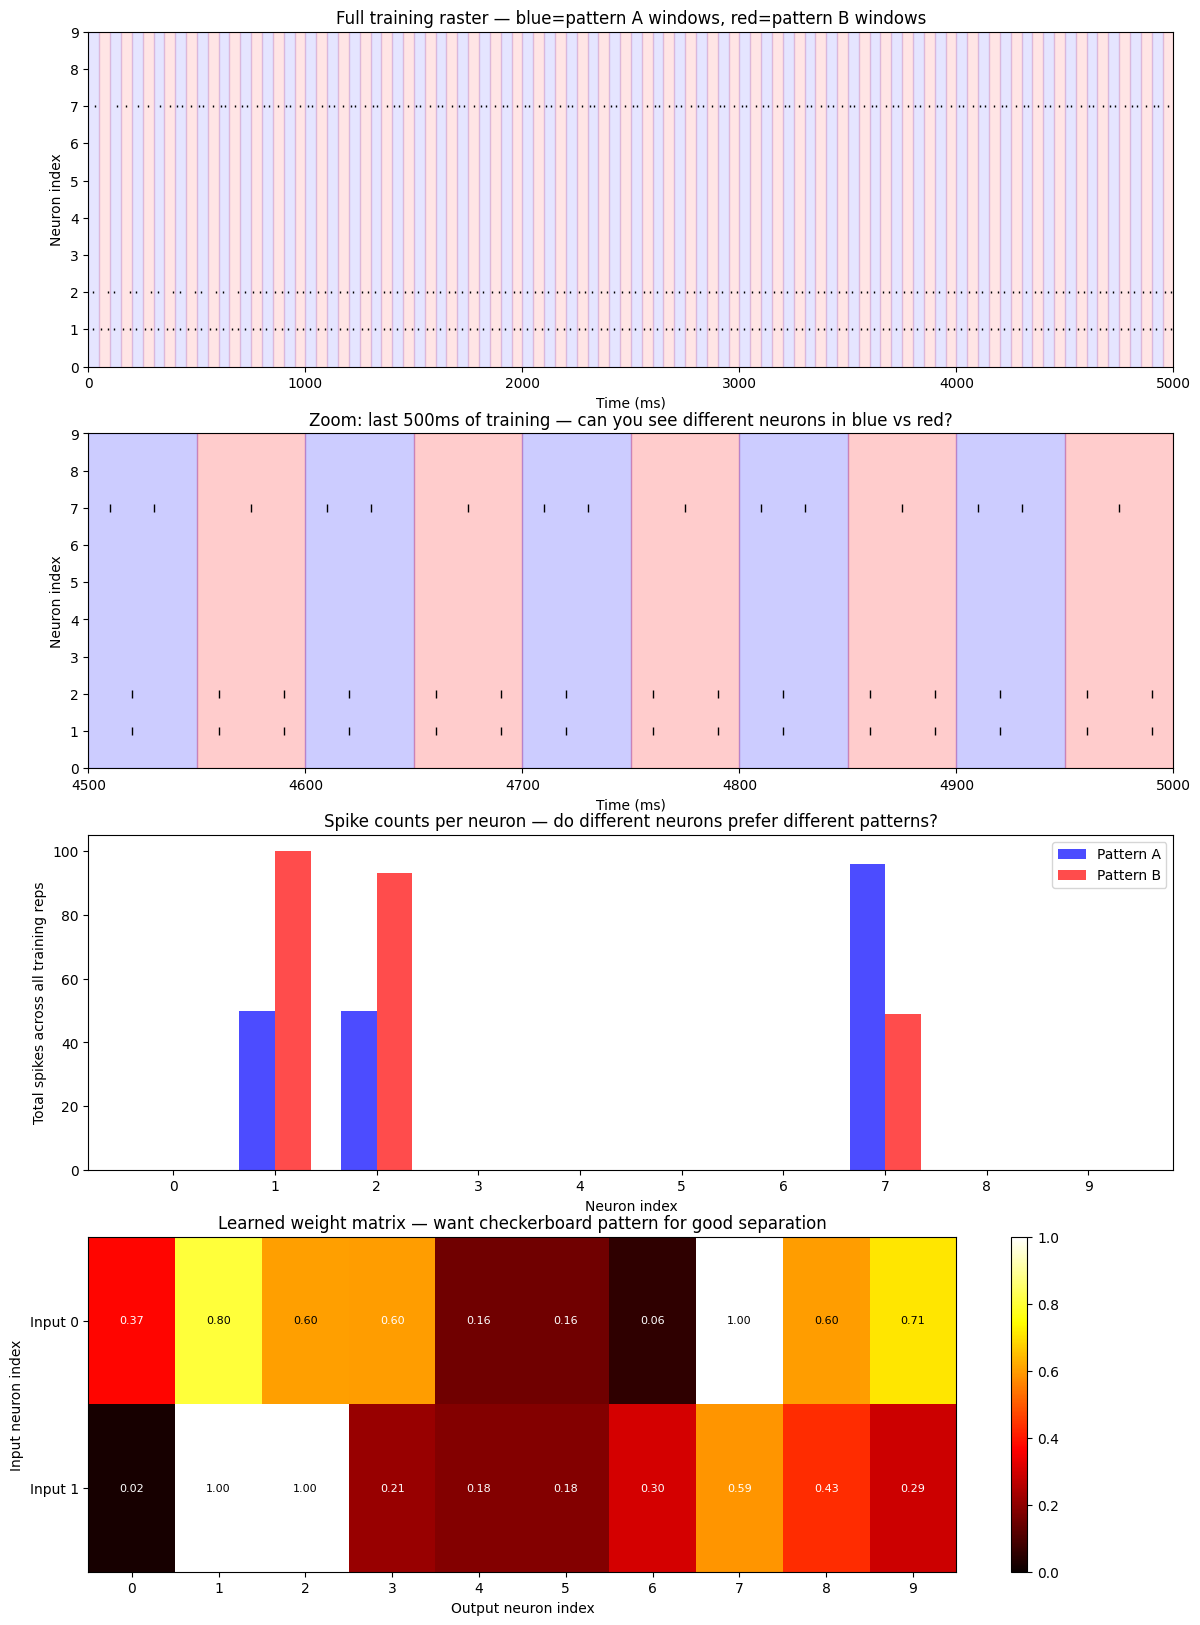

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20))

# ---- 1. Full training raster ----
ax = axes[0]
for rep in range(50):
    ax.axvspan(rep*100,     rep*100+50,  alpha=0.1, color='blue')
    ax.axvspan(rep*100+50,  rep*100+100, alpha=0.1, color='red')
ax.plot(spike_mon.t/ms, spike_mon.i, '|k', markersize=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron index')
ax.set_title('Full training raster — blue=pattern A windows, red=pattern B windows')
ax.set_xlim(0, 5000)
ax.set_yticks(range(N_exc))

# ---- 2. Zoomed raster (last 500ms) ----
ax2 = axes[1]
mask = spike_mon.t/ms >= 4500
ax2.plot(spike_mon.t[mask]/ms, spike_mon.i[mask], '|k', markersize=6)
for rep in range(45, 50):
    ax2.axvspan(rep*100,    rep*100+50,  alpha=0.2, color='blue')
    ax2.axvspan(rep*100+50, rep*100+100, alpha=0.2, color='red')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Neuron index')
ax2.set_title('Zoom: last 500ms of training — can you see different neurons in blue vs red?')
ax2.set_xlim(4500, 5000)
ax2.set_yticks(range(N_exc))

# ---- 3. Firing rate per neuron per pattern ----
# This makes the raster quantitative — instead of eyeballing, you get exact counts
ax3 = axes[2]
spike_times = spike_mon.t/ms
spike_ids   = spike_mon.i

# Count spikes per neuron in A windows vs B windows
counts_A = np.zeros(N_exc)
counts_B = np.zeros(N_exc)
for rep in range(50):
    a_start = rep * 100
    b_start = rep * 100 + 50
    in_A = spike_ids[(spike_times >= a_start) & (spike_times < a_start + 50)]
    in_B = spike_ids[(spike_times >= b_start) & (spike_times < b_start + 50)]
    for n in in_A: counts_A[n] += 1
    for n in in_B: counts_B[n] += 1

x = np.arange(N_exc)
width = 0.35
ax3.bar(x - width/2, counts_A, width, label='Pattern A', color='blue',  alpha=0.7)
ax3.bar(x + width/2, counts_B, width, label='Pattern B', color='red',   alpha=0.7)
ax3.set_xlabel('Neuron index')
ax3.set_ylabel('Total spikes across all training reps')
ax3.set_title('Spike counts per neuron — do different neurons prefer different patterns?')
ax3.set_xticks(x)
ax3.legend()

# ---- 4. Weight matrix ----
ax4 = axes[3]
W  = np.array(learned_weights).reshape(2, N_exc)
im = ax4.imshow(W, aspect='auto', cmap='hot', vmin=0, vmax=1)
ax4.set_xlabel('Output neuron index')
ax4.set_ylabel('Input neuron index')
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Input 0', 'Input 1'])
ax4.set_title('Learned weight matrix — want checkerboard pattern for good separation')
ax4.set_xticks(range(N_exc))
# Print actual weight values on each cell so you don't have to guess from colour
for i in range(2):
    for j in range(N_exc):
        ax4.text(j, i, f'{W[i,j]:.2f}', ha='center', va='center',
                 color='white' if W[i,j] < 0.6 else 'black', fontsize=8)
plt.colorbar(im, ax=ax4)

### Output:
Looking at the graphs we can get a pretty good idea for how the model performed and how learning altered synapse connections after 50 repititions of the input

#### Raster Plot:
Each tick is one spike, the y-axis shows which neuron is firing and the x-axis shows the time that it does fire, we've highlighted the portions of the graph correspond to Pattern A firing and Pattern B firing as blue and red respectively. \
Looking at the graph shows us that a specific pattern of neurons fires when pattern A fires, and a different pattern of neurons fires when pattern B fires; however, the set of firing neurons are not exclusive. We can see that some neurons fire for both patterns and some fire for neither. We need more competition

#### Spike Counts: 
We can see that although neurons 1, 2 and 7 prefer specific patterns, they are still firing for both patterns A and B. There isn't enough competition between firing for one pattern and not for another.

#### Weight Matrix:
Each cell is the strength of one synapse. Row = which input neuron is sending. Column = which output neuron is receiving. Bright = strong connection, dark = weak/dead connection.
So if cell (Input 1, neuron 4) is bright yellow, it means Input 1 has a very strong connection to output neuron 4 — when Input 1 fires, it pushes neuron 4 hard toward threshold.
We're looking for a checkerboard-ish pattern - some columns bright on top and dark on bottom, others dark on top and bright on bottom. That means different output neurons are owned by different input neurons. But looking at the output, the only neurons that somewhat resemble a checkboard are neurons 1, 2 and 7, mimicking what we saw in the spike counts plot. Most other neurons are muddled and didn't choose either pattern, that's a problem

## Experiment 2: Altering Excitatory Neuron equation
### Input Neurons (SpikeGenerator):
Pattern A: N_0 fires at 10ms, N_1 fires at 20ms, N_3 fires at 30ms \
Pattern B: N_1 fires at 10ms, N_0 fires at 25ms, N_3 fires at 40ms

We build the input as 2 neurons in a spike generating group that mimics the following: \
Pattern A fires, 50ms gap, Pattern B fires ... 50 times

### Excitatory Neurons:
There are 10 total excitatory neurons modelled by the following form of a current based LIF neuron equation: \
<br>
$\frac{dv}{dt} = \frac{-(v - v_{rest}) + I}{tau_m}$ \
<br>
$\frac{dI}{dt} = \frac{-I}{tau_s}$ \
<br>
We also introduce units for each equation. 

### Justification for change:
In the previous example the excitatory neurons followed the equation: \
$\frac{dv}{dt} = -\frac{v}{tau}$ \
where spike input was added directly to the voltage. In the new model, a 'middleman' of current (I) is introduced. Since this current follows its own decay equation, it accumulates over multiple spikes and drives the voltage to rise gradually rather than jumping instantly. This makes the neuron sensitive to the temporal density of inputs. Because STDP (Spike-Timing-Dependent Plasticity) relies on precise timing between spikes, this current-based approach is much better suited for solving temporal encoding problems.

### Synapses:
The synapses follow the standard STDP rules: 
* Define pre and post traces per synapse that decay after spikes (decay are driven by events and not by clock for performance) 
* Pre and Post traces jump when a spike occurs. 
* On pre spikes, we set the value of the synapse weight to be the previous weight + the value of the post_spike trace (pre spike changes if there was recently post spike activity)

In [13]:
seed(42)
start_scope()

# ---------------- Helper ----------------
def add_pattern(indices, times, base_t, p_idx, p_times):
    indices += p_idx
    times += [base_t + t for t in p_times]

# ---------------- Spike patterns ----------------
pattern_A_indices = [0, 1, 0]
pattern_A_times   = [10, 20, 30]*ms
pattern_B_indices = [1, 0, 1]
pattern_B_times   = [10, 25, 40]*ms

indices = []
times   = []
t       = 0*ms
gap     = 50*ms

for _ in range(50):
    add_pattern(indices, times, t, pattern_A_indices, pattern_A_times)
    t += gap
    add_pattern(indices, times, t, pattern_B_indices, pattern_B_times)
    t += gap

G_input = SpikeGeneratorGroup(2, indices, times)

# ---------------- Excitatory neurons ----------------
v_rest = -70*mV
v_thresh = -55*mV
tau_m = 10*ms
tau_s = 7*ms # My logic for choosing 7ms...
"""
So tau_s is the time that it takes for I to decay. We want patterns close to each other to bump I up more right? So
given patterns A and B with a 50ms gap between them, the ROUGHLY average time between spikes during the patterns is between 10 and 5ms, I 
went with 7ms. Essentially I decays in 7ms, but if anotherspike occurs during or close after that time, the value of I 
jumps up more, giving us more info from the relative time between spikes, we can experiment with values of tau_s between 5ms and 10ms
"""

N_exc = 10
eqs = '''
dv/dt = (-(v - v_rest) + I) / tau_m : volt
dI/dt = -I / tau_s : volt
'''
G_exc = NeuronGroup(N_exc, eqs,
                    threshold='v > v_thresh',
                    reset='v = v_rest',
                    method='exact',
                    namespace={'v_rest': v_rest, 'v_thresh': v_thresh})
G_exc.v = v_rest
G_exc.I = 0*mV

# ---------------- STDP Synapses ----------------
taupre = taupost = 20*ms
Apre  = 0.01
Apost = -Apre*taupre/taupost*1.05
wmax  = 1

S = Synapses(G_input, G_exc,
             '''
             w : 1
             dapre/dt = -apre / taupre : 1 (event-driven)
             dapost/dt = -apost / taupost : 1 (event-driven)
             ''',
             on_pre='''
             I_post += w*47*mV # SEE THE DIAGNOSTIC CELL BELOW ON HOW WE ARRIVED AT THE SCALE VALUE OF 47! (Lower doesn't cause it to spike at all)
             apre += Apre
             w = clip(w + apost, 0, wmax)
             ''',
             on_post='''
             apost += Apost
             w = clip(w + apre, 0, wmax)
             ''')
S.connect()
S.w = 'rand()'

# ---------------- Monitors ----------------
spike_mon  = SpikeMonitor(G_exc)
weight_mon = StateMonitor(S, 'w', record=True)

# ---------------- Train ----------------
run(5000*ms)

learned_weights = S.w[:]

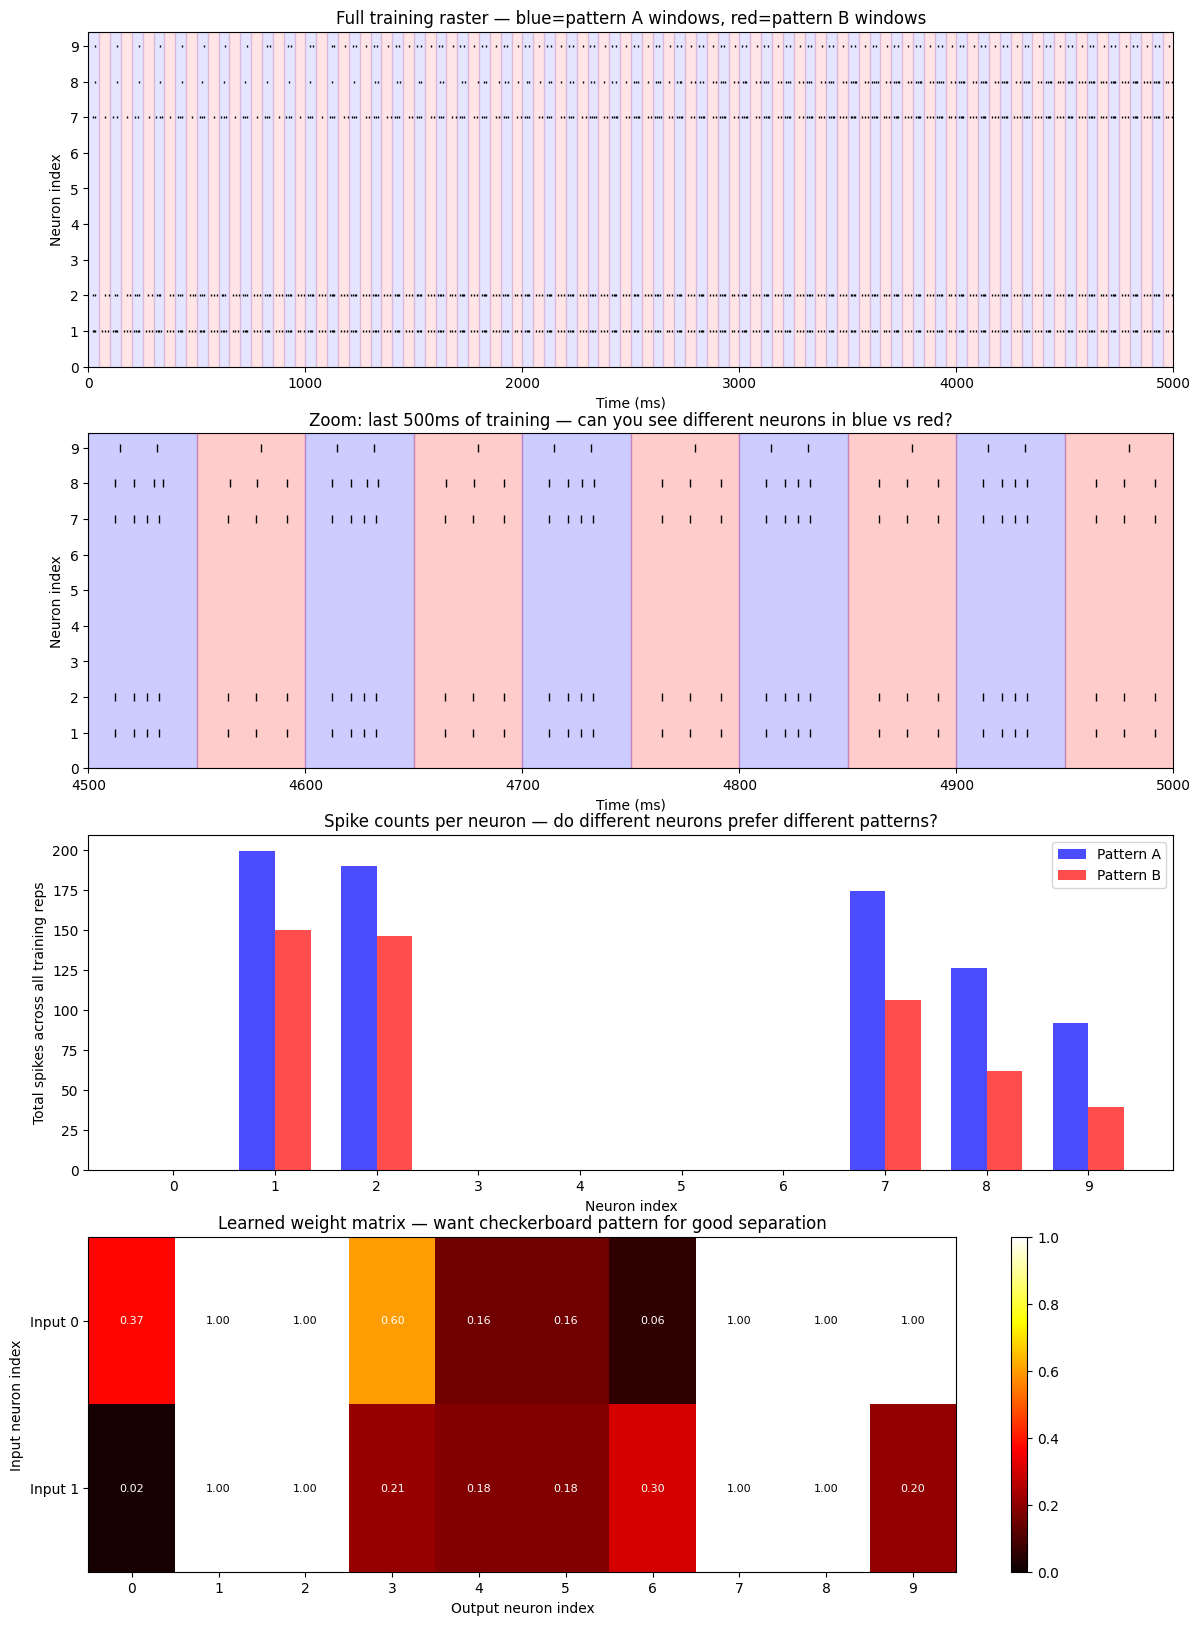

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20))

# ---- 1. Full training raster ----
ax = axes[0]
for rep in range(50):
    ax.axvspan(rep*100,     rep*100+50,  alpha=0.1, color='blue')
    ax.axvspan(rep*100+50,  rep*100+100, alpha=0.1, color='red')
ax.plot(spike_mon.t/ms, spike_mon.i, '|k', markersize=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron index')
ax.set_title('Full training raster — blue=pattern A windows, red=pattern B windows')
ax.set_xlim(0, 5000)
ax.set_yticks(range(N_exc))

# ---- 2. Zoomed raster (last 500ms) ----
ax2 = axes[1]
mask = spike_mon.t/ms >= 4500
ax2.plot(spike_mon.t[mask]/ms, spike_mon.i[mask], '|k', markersize=6)
for rep in range(45, 50):
    ax2.axvspan(rep*100,    rep*100+50,  alpha=0.2, color='blue')
    ax2.axvspan(rep*100+50, rep*100+100, alpha=0.2, color='red')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Neuron index')
ax2.set_title('Zoom: last 500ms of training — can you see different neurons in blue vs red?')
ax2.set_xlim(4500, 5000)
ax2.set_yticks(range(N_exc))

# ---- 3. Firing rate per neuron per pattern ----
# This makes the raster quantitative — instead of eyeballing, you get exact counts
ax3 = axes[2]
spike_times = spike_mon.t/ms
spike_ids   = spike_mon.i

# Count spikes per neuron in A windows vs B windows
counts_A = np.zeros(N_exc)
counts_B = np.zeros(N_exc)
for rep in range(50):
    a_start = rep * 100
    b_start = rep * 100 + 50
    in_A = spike_ids[(spike_times >= a_start) & (spike_times < a_start + 50)]
    in_B = spike_ids[(spike_times >= b_start) & (spike_times < b_start + 50)]
    for n in in_A: counts_A[n] += 1
    for n in in_B: counts_B[n] += 1

x = np.arange(N_exc)
width = 0.35
ax3.bar(x - width/2, counts_A, width, label='Pattern A', color='blue',  alpha=0.7)
ax3.bar(x + width/2, counts_B, width, label='Pattern B', color='red',   alpha=0.7)
ax3.set_xlabel('Neuron index')
ax3.set_ylabel('Total spikes across all training reps')
ax3.set_title('Spike counts per neuron — do different neurons prefer different patterns?')
ax3.set_xticks(x)
ax3.legend()

# ---- 4. Weight matrix ----
ax4 = axes[3]
W  = np.array(learned_weights).reshape(2, N_exc)
im = ax4.imshow(W, aspect='auto', cmap='hot', vmin=0, vmax=1)
ax4.set_xlabel('Output neuron index')
ax4.set_ylabel('Input neuron index')
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Input 0', 'Input 1'])
ax4.set_title('Learned weight matrix — want checkerboard pattern for good separation')
ax4.set_xticks(range(N_exc))
# Print actual weight values on each cell so you don't have to guess from colour
for i in range(2):
    for j in range(N_exc):
        ax4.text(j, i, f'{W[i,j]:.2f}', ha='center', va='center',
                 color='white' if W[i,j] < 0.6 else 'black', fontsize=8)
plt.colorbar(im, ax=ax4)

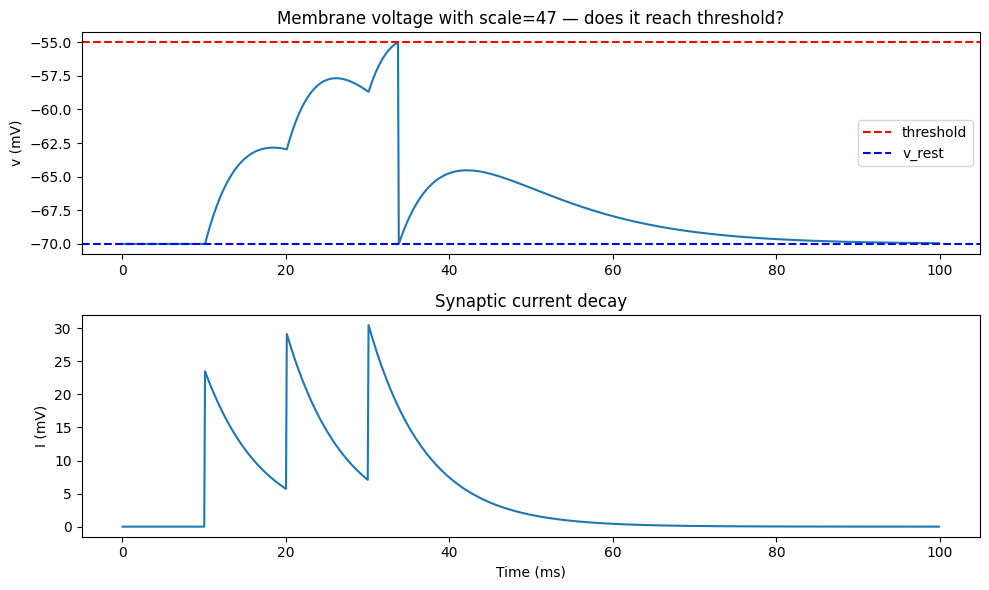

Neuron fired: 1 times
Max voltage reached: -55.02 mV


In [15]:
# ---- Diagnostic: can a single neuron even fire? ----
start_scope()

v_rest   = -70*mV
v_thresh = -55*mV
tau_m    = 10*ms
tau_s    = 7*ms

eqs = '''
dv/dt = (-(v - v_rest) + I) / tau_m : volt
dI/dt = -I / tau_s : volt
'''

test_neuron = NeuronGroup(1, eqs,
                          threshold='v > v_thresh',
                          reset='v = v_rest',
                          method='exact',
                          namespace={'v_rest': v_rest, 'v_thresh': v_thresh})
test_neuron.v = v_rest
test_neuron.I = 0*mV

scale = 47  # tune this number until neuron fires

spikes_test = SpikeGeneratorGroup(1, [0, 0, 0], [10, 20, 30]*ms)
S_diag = Synapses(spikes_test, test_neuron, 'w:1', on_pre='I_post += w*scale*mV')
S_diag.connect()
S_diag.w = 0.5  # average starting weight

v_mon = StateMonitor(test_neuron, ['v', 'I'], record=True)
spike_mon_diag = SpikeMonitor(test_neuron)

diag_net = Network(test_neuron, spikes_test, S_diag, v_mon, spike_mon_diag)
diag_net.run(100*ms)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(v_mon.t/ms, v_mon.v[0]/mV)
axes[0].axhline(-55, color='red', linestyle='--', label='threshold')
axes[0].axhline(-70, color='blue', linestyle='--', label='v_rest')
axes[0].set_ylabel('v (mV)')
axes[0].set_title(f'Membrane voltage with scale={scale} — does it reach threshold?')
axes[0].legend()

axes[1].plot(v_mon.t/ms, v_mon.I[0]/mV)
axes[1].set_ylabel('I (mV)')
axes[1].set_xlabel('Time (ms)')
axes[1].set_title('Synaptic current decay')

plt.tight_layout()
plt.show()

print(f"Neuron fired: {spike_mon_diag.num_spikes} times")
print(f"Max voltage reached: {max(v_mon.v[0])/mV:.2f} mV")

### Output:
Now that we added the difference in neuron equation, we can see that more neurons are firing and more easily so that's a good sign. But now the problem of competition is becoming even more prevenlant. \
Looking at the spike counts, we can see that every neuron that is firing is starting to prefer pattern A just due to the nature of the pattern, and looking at the weight matrix, we have several neurons which have completely saturated weights! \
In our model, we already have the value of A_post being larger relative to A_pre which should be preventing weight saturation for the most part, but we are still getting weight values reaching the maximum, this points to a different problem, competition. \
In the next 2 experiments we will tackle this issue to make our model more robust.